# Phase 2 — Exploratory Data Analysis (EDA)

Visualize churn patterns across customer demographics, services, and account features. Identify which features are strong churn predictors before modeling.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set plot style
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Create output directory for saved figures
os.makedirs('../outputs/figures', exist_ok=True)

# Load cleaned dataset from Phase 1
df = pd.read_csv('../data/telco_churn_cleaned.csv')
print(f"Loaded: {df.shape}")

Loaded: (7032, 20)


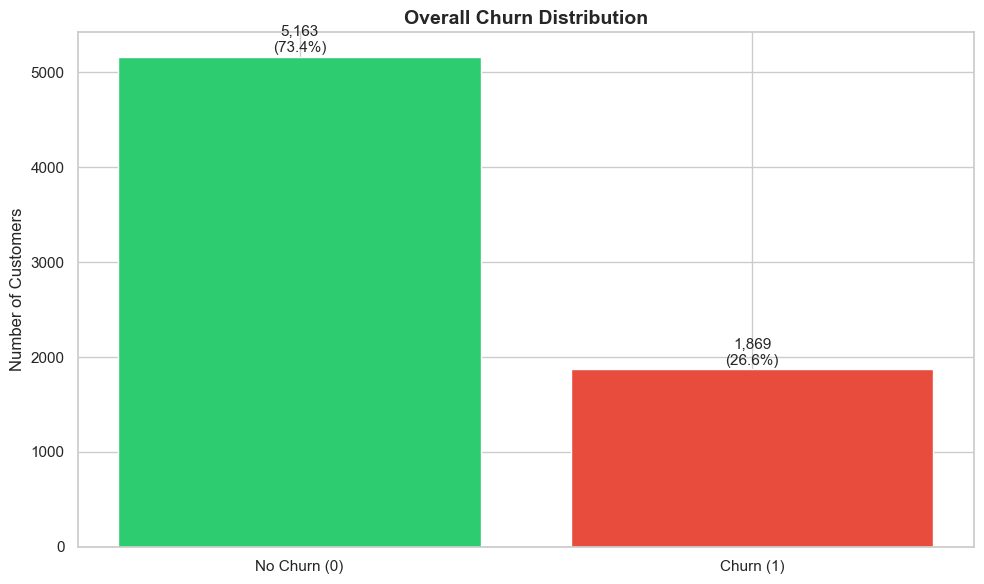

In [2]:
# 1. Overall churn distribution
fig, ax = plt.subplots()
churn_counts = df['Churn'].value_counts()
bars = ax.bar(['No Churn (0)', 'Churn (1)'], churn_counts.values, color=['#2ecc71', '#e74c3c'])
ax.set_title('Overall Churn Distribution', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Customers')

# Add count labels on bars
for bar, count in zip(bars, churn_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, 
            f'{count:,}\n({count/len(df)*100:.1f}%)', ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('../outputs/figures/churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

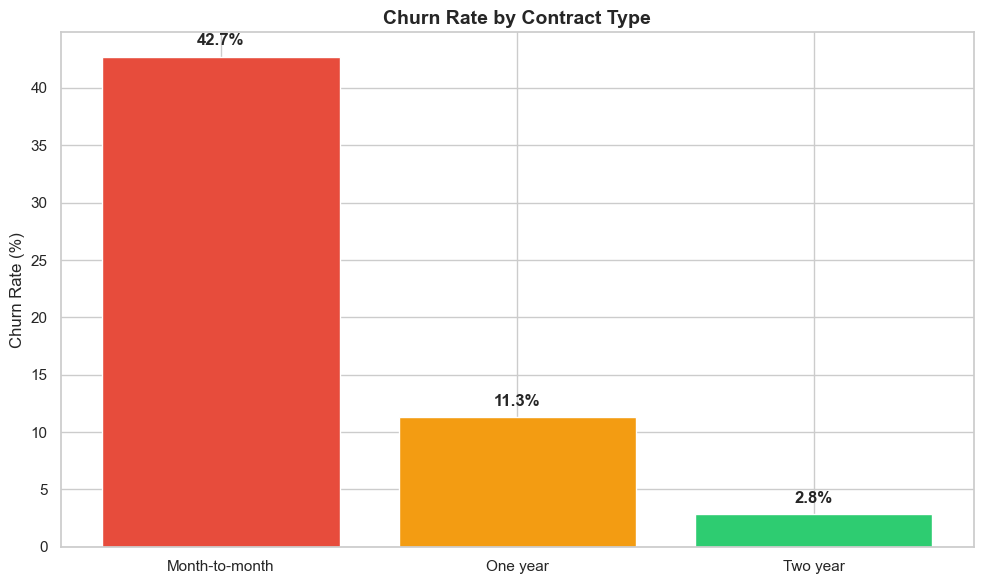

In [3]:
# 2. Churn rate by Contract type (key finding — saved separately for Streamlit)
fig, ax = plt.subplots()
contract_churn = df.groupby('Contract')['Churn'].mean().sort_values(ascending=False)
bars = ax.bar(contract_churn.index, contract_churn.values * 100, 
              color=['#e74c3c', '#f39c12', '#2ecc71'])
ax.set_title('Churn Rate by Contract Type', fontsize=14, fontweight='bold')
ax.set_ylabel('Churn Rate (%)')

for bar, rate in zip(bars, contract_churn.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
            f'{rate*100:.1f}%', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/figures/churn_by_contract.png', dpi=150, bbox_inches='tight')
plt.show()

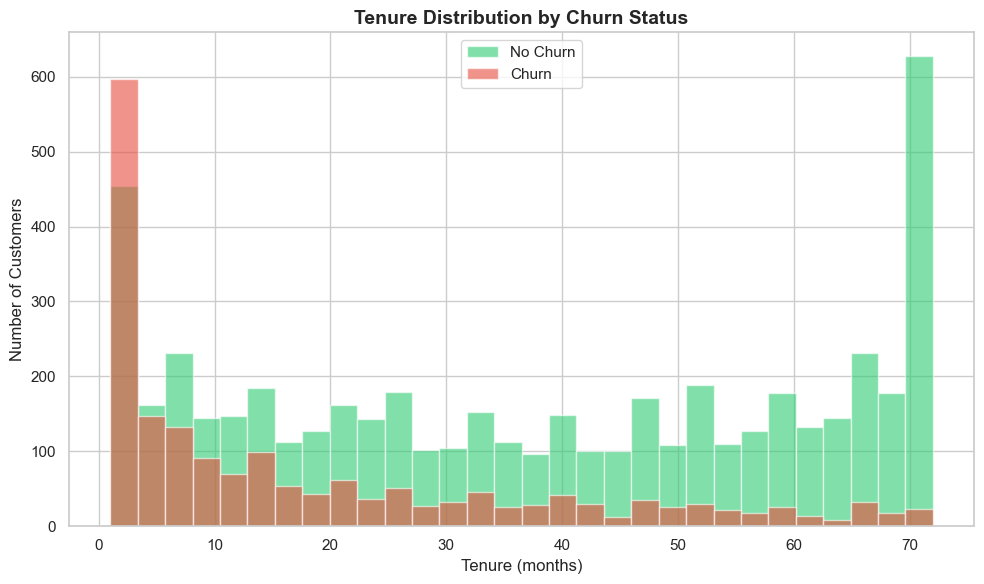

In [4]:
# 3. Tenure distribution by churn status (saved for Streamlit)
fig, ax = plt.subplots()
df[df['Churn']==0]['tenure'].hist(bins=30, alpha=0.6, color='#2ecc71', label='No Churn', ax=ax)
df[df['Churn']==1]['tenure'].hist(bins=30, alpha=0.6, color='#e74c3c', label='Churn', ax=ax)
ax.set_title('Tenure Distribution by Churn Status', fontsize=14, fontweight='bold')
ax.set_xlabel('Tenure (months)')
ax.set_ylabel('Number of Customers')
ax.legend()

plt.tight_layout()
plt.savefig('../outputs/figures/tenure_by_churn.png', dpi=150, bbox_inches='tight')
plt.show()

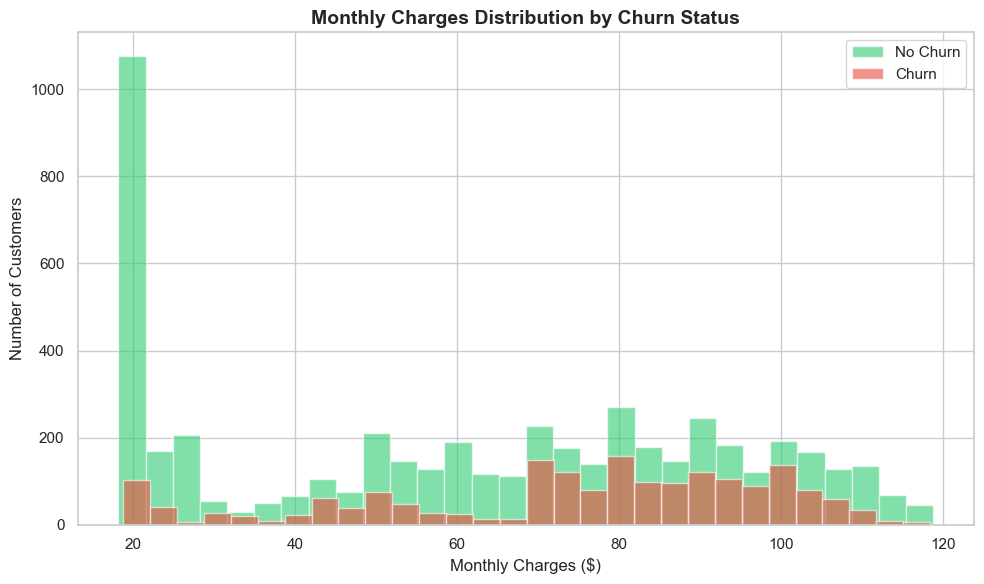

In [5]:
# 4. Monthly charges distribution by churn status
fig, ax = plt.subplots()
df[df['Churn']==0]['MonthlyCharges'].hist(bins=30, alpha=0.6, color='#2ecc71', label='No Churn', ax=ax)
df[df['Churn']==1]['MonthlyCharges'].hist(bins=30, alpha=0.6, color='#e74c3c', label='Churn', ax=ax)
ax.set_title('Monthly Charges Distribution by Churn Status', fontsize=14, fontweight='bold')
ax.set_xlabel('Monthly Charges ($)')
ax.set_ylabel('Number of Customers')
ax.legend()

plt.tight_layout()
plt.savefig('../outputs/figures/monthly_charges_by_churn.png', dpi=150, bbox_inches='tight')
plt.show()

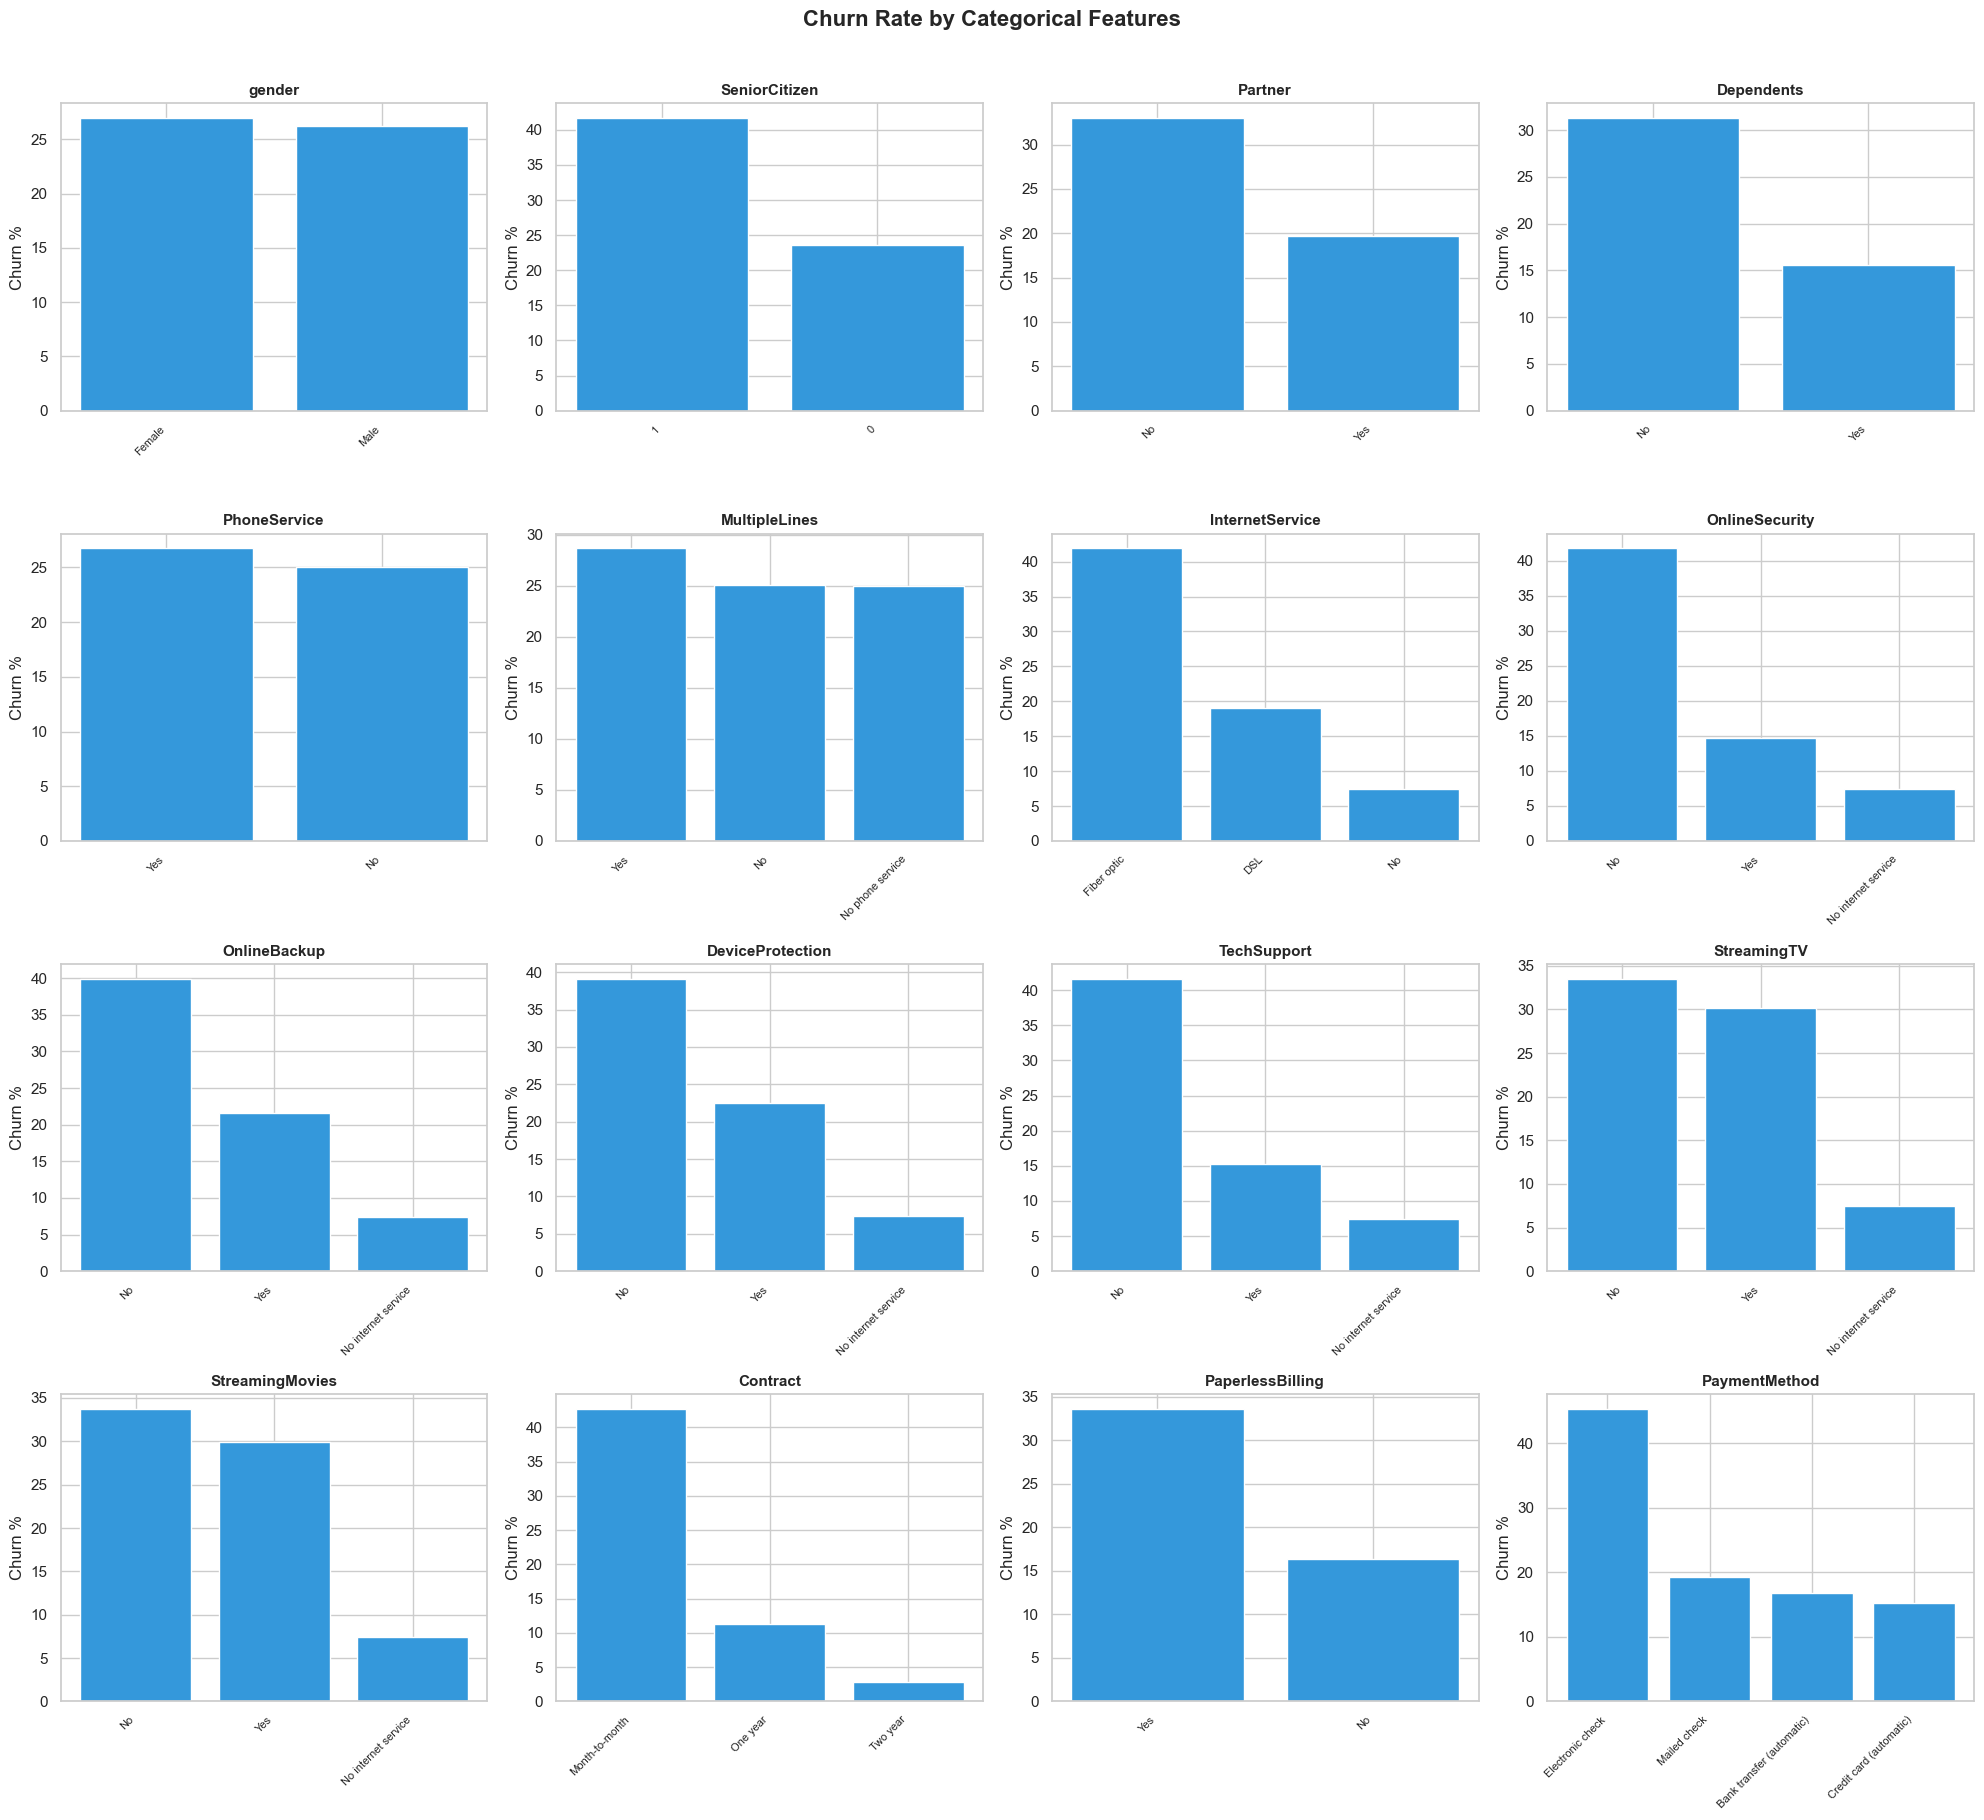

In [6]:
# 5. Churn rate by all key categorical features
cat_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
            'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
            'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
            'Contract', 'PaperlessBilling', 'PaymentMethod']

fig, axes = plt.subplots(4, 4, figsize=(20, 18))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    churn_rate = df.groupby(col)['Churn'].mean().sort_values(ascending=False)
    axes[i].bar(range(len(churn_rate)), churn_rate.values * 100, color='#3498db')
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xticks(range(len(churn_rate)))
    axes[i].set_xticklabels(churn_rate.index, rotation=45, ha='right', fontsize=8)
    axes[i].set_ylabel('Churn %')

plt.suptitle('Churn Rate by Categorical Features', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../outputs/figures/churn_by_categories.png', dpi=150, bbox_inches='tight')
plt.show()

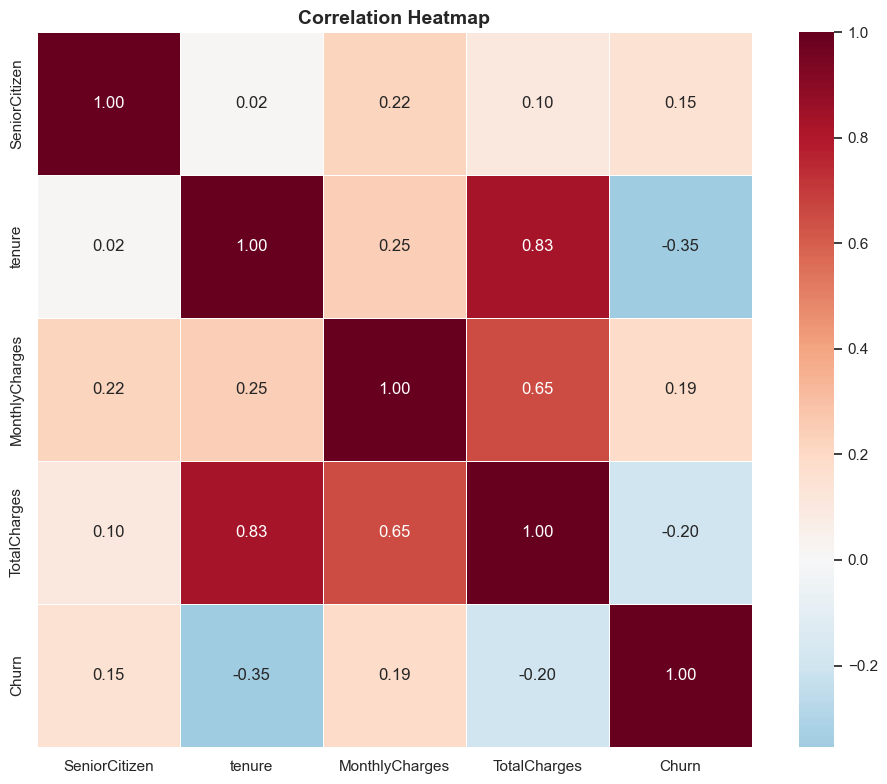

In [7]:
# 6. Correlation heatmap (numeric features + target)
fig, ax = plt.subplots(figsize=(10, 8))
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt='.2f',
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation Heatmap', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/figures/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

C:\Users\nadea\AppData\Local\Temp\ipykernel_7692\2906904678.py:8: MatplotlibDeprecationWarning: You have mixed positional and keyword arguments, some input may be discarded.  This is deprecated since 3.9 and will become an error in 3.11.
  legend = ax.legend(*scatter.legend_elements(), labels=['No Churn', 'Churn'])


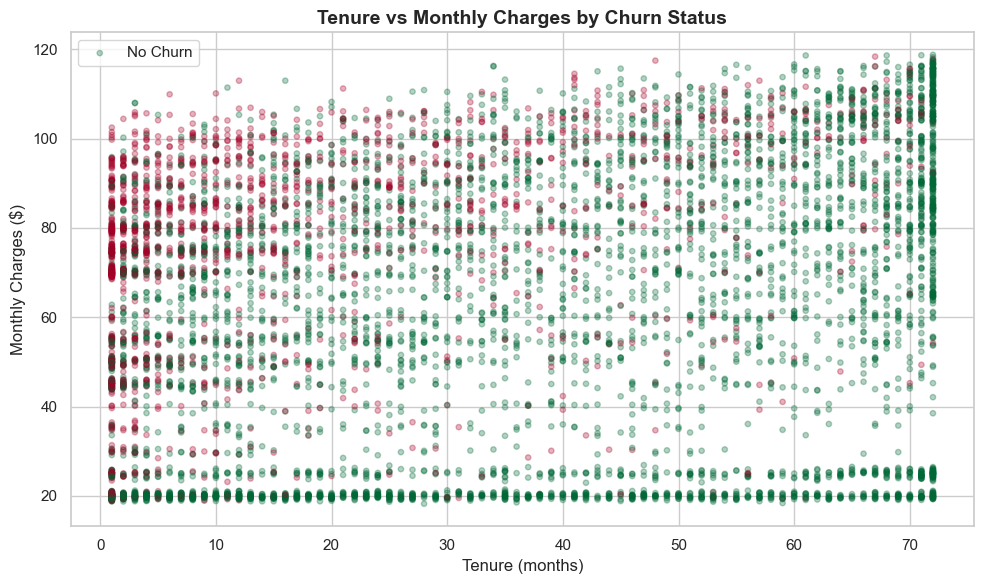

In [8]:
# 7. Scatter plot: tenure vs monthly charges colored by churn
fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(df['tenure'], df['MonthlyCharges'], 
                     c=df['Churn'], cmap='RdYlGn_r', alpha=0.3, s=15)
ax.set_title('Tenure vs Monthly Charges by Churn Status', fontsize=14, fontweight='bold')
ax.set_xlabel('Tenure (months)')
ax.set_ylabel('Monthly Charges ($)')
legend = ax.legend(*scatter.legend_elements(), labels=['No Churn', 'Churn'])

plt.tight_layout()
plt.savefig('../outputs/figures/tenure_vs_charges_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

## Phase 2 — EDA Summary

**Key Findings:**

1. **Contract type is the strongest churn predictor.** Month-to-month customers churn at 42.7% vs 11.3% (one year) and 2.8% (two year).
2. **Churn is front-loaded by tenure.** Most churners leave within the first few months. Long-tenured customers (70+ months) rarely churn.
3. **Higher monthly charges correlate with higher churn.** Churners skew toward $70–$100/month plans.
4. **Fiber optic internet customers churn at much higher rates** than DSL or no-internet customers.
5. **Lack of support add-ons increases churn.** Customers without OnlineSecurity, TechSupport, OnlineBackup, or DeviceProtection churn more.
6. **Electronic check payment method** has noticeably higher churn than other payment methods.
7. **Gender and phone service** show no meaningful difference in churn rates.

**Figures saved to `outputs/figures/`:** churn_distribution, churn_by_contract, tenure_by_churn, monthly_charges_by_churn, churn_by_categories, correlation_heatmap, tenure_vs_charges_scatter